In [1]:
from cme.diffusion_models import diffusion as dd
import cme.utils.common_logging as cl
import numpy as np
from cme.utils import common_utils as ut
import pandas as pd
import os
import pymc as pm
from pytensor import tensor as at

In [2]:
(0.2515518 + 2*0.0008319) * np.exp( ((0.2515518 + 2*0.0008319)**2) / (2*0.0008319) )

1.3802884675754678e+16

In [3]:
lp_v, v, a, z, t_er,  X, RT = dd._test_likelihood_using_prior(100, 20)
#v = 1.5
#a = 2
#z = 0.5
#t_er = 0.55

2023-06-02 15:23:22,671 - diffusion - DEBUG - Starting Diffusion test
2023-06-02 15:23:36,390 - diffusion - DEBUG - lp: 6.374516129297594
2023-06-02 15:23:36,439 - diffusion - DEBUG - X:[[0 1 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]
 [0 1 1 ... 1 0 1]
 ...
 [0 0 0 ... 0 1 0]
 [0 1 1 ... 1 0 1]
 [0 0 0 ... 1 1 1]]
2023-06-02 15:23:36,474 - diffusion - DEBUG - RT:[[2.85446013 1.03576685 2.65284397 ... 3.78499073 2.32674157 2.68891211]
 [0.48354326 2.8282953  2.74845493 ... 3.68592793 1.10276871 0.9142249 ]
 [3.52255061 0.01946326 2.39262333 ... 0.76839059 1.37910442 3.98224474]
 ...
 [2.91906985 3.07062911 2.6066804  ... 0.25961137 2.95642906 2.62228529]
 [3.07541646 0.91155535 1.94912602 ... 1.4563154  1.67512994 0.95217277]
 [3.03993596 3.14972449 1.54390496 ... 1.33314525 0.38924256 0.59514097]]
2023-06-02 15:23:36,482 - diffusion - INFO - Test Successful!


In [4]:
#import pytensor.tensor as at

In [5]:
#at.ones((100,20)).sum().eval().shape

In [6]:
RT.shape

(100, 20)

In [7]:
X.shape

(100, 20)

In [8]:
lp_v.shape

()

In [9]:
v.shape

(100, 1)

In [10]:
lp_v = [dd._test_likelihood_using_prior(100, 20)[0] for i in range(50)]


2023-06-02 15:23:37,200 - diffusion - DEBUG - Starting Diffusion test
2023-06-02 15:23:37,534 - diffusion - DEBUG - lp: 8.208411671898531
2023-06-02 15:23:37,568 - diffusion - DEBUG - X:[[1 1 0 ... 1 1 1]
 [0 0 1 ... 1 0 1]
 [0 1 1 ... 1 1 0]
 ...
 [1 0 0 ... 0 1 0]
 [1 0 0 ... 1 0 0]
 [0 1 1 ... 0 0 1]]
2023-06-02 15:23:37,608 - diffusion - DEBUG - RT:[[3.40109159 0.98381379 2.42780867 ... 2.16325014 0.73099611 3.63930059]
 [0.00798287 3.26877242 3.01812823 ... 3.54050408 3.15987816 0.58354554]
 [2.83324141 3.89076026 1.86084554 ... 1.24330536 1.33140413 2.13943346]
 ...
 [1.26690525 3.57798515 3.44991684 ... 3.22599099 2.75311252 1.99430211]
 [2.5383951  1.75625438 2.5780797  ... 1.08586352 3.68811171 0.10942149]
 [0.51396116 0.20555779 0.16294309 ... 1.69148344 3.60293287 1.57213301]]
2023-06-02 15:23:37,608 - diffusion - INFO - Test Successful!
2023-06-02 15:23:37,674 - diffusion - DEBUG - Starting Diffusion test
2023-06-02 15:23:38,000 - diffusion - DEBUG - lp: 6.689845238367557
2

In [11]:
lp_v

[array(8.20841167),
 array(6.68984524),
 array(10.19428098),
 array(7.4048014),
 array(6.15736722),
 array(5.56005475),
 array(6.83262608),
 array(7.72739762),
 array(7.95581115),
 array(7.32485261),
 array(7.51131044),
 array(6.54259613),
 array(6.33682719),
 array(6.76638004),
 array(7.71890196),
 array(5.90861836),
 array(4.62504731),
 array(8.47354898),
 array(6.44249152),
 array(8.14161287),
 array(6.52439567),
 array(9.58407916),
 array(7.25360394),
 array(9.01786794),
 array(10.78724146),
 array(5.92244814),
 array(5.45550049),
 array(6.35192036),
 array(7.82683351),
 array(7.48619106),
 array(6.68471669),
 array(12.65107995),
 array(8.16407382),
 array(9.72739952),
 array(5.78231888),
 array(6.85514683),
 array(5.74515855),
 array(8.49336231),
 array(4.98480724),
 array(6.1461992),
 array(10.65107586),
 array(6.52649863),
 array(7.42300254),
 array(6.93057356),
 array(5.83832935),
 array(8.83435653),
 array(10.53510181),
 array(9.34637742),
 array(11.77140802),
 array(7.0234489

In [12]:
RT.mean(axis=1).shape

(100,)

In [13]:
lp_v = np.asarray(lp_v)

In [14]:
lp_v.shape

(50,)

<AxesSubplot:>

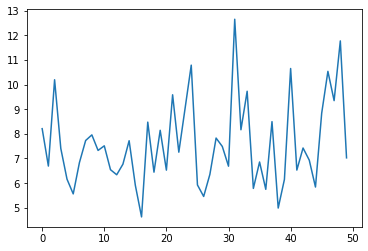

In [15]:
pd.Series(lp_v).plot()

In [16]:
#df = pd.DataFrame({"lp":lp_v.flatten(), "RT":RT.mean(axis=1).flatten()})
#df

In [17]:
#df.plot(x="RT", y="lp", kind="scatter")

In [18]:
#df.loc[:,"lp"].plot(kind="box")

In [19]:
np.save("v.npy",v)
np.save("a.npy",a)
np.save("z.npy",z)
np.save("t_er.npy",t_er)
np.save("X.npy",X)
np.save("RT.npy",RT)

In [20]:
#prior_chain = dd.sample_prior_data(10,2,9)

In [21]:
#post_chain = dd.sample_posterior_params(RT, X, 10,2,10)
